In [ ]:
import pandas as pd
import numpy as np
!pip install snowflake-connector-python
import snowflake.connector

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 4.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found e

In [ ]:
con = snowflake.connector.connect(
    user ='ManasaRubini',
    password = 'xxxxxxxxxxxxxxx',
    account = 'xxxxxxxxxxxxxxxxxxxxxxxxxxxxx',
    database = 'DETAILS',
    schema = 'PUBLIC',
    warehouse ='COMPUTE_WH'
)

In [ ]:
query = 'select * from water_potability'
df = pd.read_sql(query,con)
con.close()

/tmp/ipykernel_1522/796496519.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,con)


In [ ]:
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())
print(df.shape)
print(df.isnull().sum())

         PH    HARDNESS        SOLIDS  CHLORAMINES     SULFATE  CONDUCTIVITY  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
            PH    HARDNESS        SOLIDS  CHLORAMINES     SULFATE  \
3271  4.668102  193.681735  47580.991603     7.166639  359.948574   
3272  7.808856  193.5

In [ ]:
df.isnull().sum()

,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


In [ ]:
# handling missing values
df[['PH','SULFATE','TRIHALOMETHANES']]=df[['PH','SULFATE','TRIHALOMETHANES']].fillna(df[['PH','SULFATE','TRIHALOMETHANES']].mean())

In [ ]:
df.isnull().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0
POTABILITY,0


In [ ]:
from scipy.stats import zscore
z = zscore(df)
df[np.abs(z)>3]

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
37,5.618064,304.235912,17281.975168,6.101084,333.775777,399.471566,12.265002,81.588992,2.896547,0
61,6.391354,213.017830,20965.478309,5.375560,327.650543,369.338121,13.758105,17.915723,3.923749,0
66,5.058109,238.569380,34873.934523,8.983276,374.433505,669.725086,13.353181,76.521800,5.106656,0
80,1.844538,233.764343,28689.595778,7.724432,333.775777,410.387264,15.611859,54.299444,5.013463,0
88,10.155440,300.292476,12652.362979,6.655126,398.647786,487.459131,9.347634,67.919789,5.002467,0
...,...,...,...,...,...,...,...,...,...,...
3190,9.293622,193.061723,50166.533323,6.301884,333.775777,365.439202,14.225917,98.625457,3.661882,1
3221,4.034063,303.702627,33219.074545,4.425559,333.775777,494.320907,13.415230,72.012642,5.024742,1
3226,7.870853,210.627825,51731.820553,6.190963,333.775777,533.291262,15.029899,84.335058,4.221614,1
3269,11.491011,94.812545,37188.826022,9.263166,258.930600,439.893618,16.172755,41.558501,4.369264,1


<Axes: >

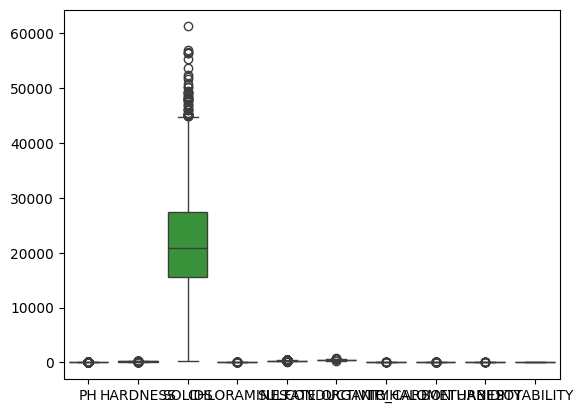

In [ ]:
import seaborn as sns
sns.boxplot(df)

In [ ]:
from scipy.stats.mstats import winsorize
cols = ['PH', 'HARDNESS','SOLIDS','CHLORAMINES', 'SULFATE','CONDUCTIVITY','ORGANIC_CARBON', 'TRIHALOMETHANES','TURBIDITY']

for col in cols:
    df[col] = winsorize(df[col], limits=[0, 0.1])

<Axes: >

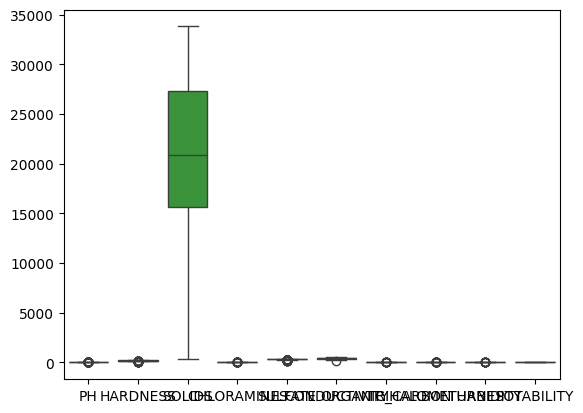

In [ ]:
sns.boxplot(df)

In [ ]:
from scipy.stats import zscore
z = zscore(df)
df[np.abs(z)>3]

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
51,7.809632,100.457615,12013.550629,5.212315,247.200826,533.303221,9.611349,66.084174,2.447444,0
61,6.391354,213.017830,20965.478309,5.375560,327.650543,369.338121,13.758105,17.915723,3.923749,0
67,7.080795,103.464759,27420.167425,8.417305,333.775777,485.974500,11.351133,67.869964,4.620793,0
80,1.844538,233.764343,28689.595778,7.724432,333.775777,410.387264,15.611859,54.299444,4.977324,0
104,2.612036,188.804126,33820.645760,6.796439,333.775777,468.080267,13.170763,49.523770,4.765205,0
...,...,...,...,...,...,...,...,...,...,...
3088,2.128531,192.696422,24905.284521,7.757770,378.526141,473.550065,14.286493,56.347830,3.842109,0
3094,1.985383,216.480025,23039.328505,6.769268,344.014256,341.078379,11.498237,78.733441,3.923093,0
3179,8.926113,94.908977,16598.577511,9.124225,311.296157,533.303221,12.312032,67.426955,4.016410,1
3217,7.080795,98.367915,28415.575832,9.124225,296.843208,505.240269,12.882614,85.329955,4.119087,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

x=df.drop('POTABILITY',axis=1)
y=df['POTABILITY']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
from sklearn.preprocessing import RobustScaler

rs= RobustScaler()
x_train = rs.fit_transform(x_train)
x_test = rs.transform(x_test)

In [ ]:
from sklearn.svm import SVC

svc = SVC( kernel='rbf')
svc.fit(x_train,y_train)
print("Accuracy Score : ",accuracy_score(y_test,y_pred))

Accuracy Score :  0.6800976800976801
